In [1]:
# ============ 셀 1: 설정 ============
import os, re, json, time, math, random, shutil, copy
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
import torchvision
from PIL import Image
from multiprocessing import Pool

assert torch.cuda.is_available(), "GPU가 꺼져 있어요. Settings → Accelerator → GPU T4 로 바꾸세요."
DEV = 'cuda'
torch.backends.cudnn.benchmark = True

OUT  = '/kaggle/working/exp_adamw'   # 결과 (작은 파일들)
DATA = '/tmp/data'                   # 전처리한 이미지 (큰 파일, 결과물에 안 섞이게)
os.makedirs(OUT, exist_ok=True); os.makedirs(DATA, exist_ok=True)

CFG = dict(
    seed=0, store=136, crop=128,
    # 사전학습: ImageNet-100, ResNet-18, AdamW, WSD
    pre_epochs=100, pre_bs=256, pre_lr=2e-3, pre_wd=0.05, pre_warmup_epochs=5,
    decay_frac=0.2, pre_rho=0.10, label_smooth=0.1,
    # 파인튜닝: FGVC Aircraft, AdamW (rho=0.05는 SAM 원 논문의 파인튜닝 값)
    ft_epochs=30, ft_bs=64, ft_lr=1e-3, ft_wd=0.05, ft_warmup_epochs=1, ft_rho=0.05, ft_eval_every=2,
    # 측정
    probe_epochs=30, hvp_iters=20,
)
json.dump(CFG, open(f'{OUT}/config.json', 'w'), indent=2)

def seed_all(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)

print('GPU :', torch.cuda.get_device_name(0))
print('torch', torch.__version__, '| torchvision', torchvision.__version__, '| CPU', os.cpu_count())
for d in ['/kaggle/working', '/tmp']:
    print(f'{d} 여유 공간: {shutil.disk_usage(d).free/1e9:.1f} GB')

GPU : Tesla T4
torch 2.10.0+cu128 | torchvision 0.25.0+cu128 | CPU 4
/kaggle/working 여유 공간: 20.9 GB
/tmp 여유 공간: 1201.7 GB


In [2]:
# ============ 셀 2: ImageNet-100 찾아서 136px로 전처리 (한 번만) ============
S = CFG['store']

def load_resize(path, crop_bottom=0):
    try:
        im = Image.open(path)
        im.draft('RGB', (S * 2, S * 2))
        im = im.convert('RGB')
        if crop_bottom:
            w, h = im.size; im = im.crop((0, 0, w, h - crop_bottom))
        w, h = im.size; s = S / min(w, h)
        im = im.resize((max(S, round(w * s)), max(S, round(h * s))), Image.BILINEAR)
        w, h = im.size; l, t = (w - S) // 2, (h - S) // 2
        return np.asarray(im.crop((l, t, l + S, t + S)), dtype=np.uint8)
    except Exception as e:
        print('읽기 실패:', path, e)
        return np.zeros((S, S, 3), np.uint8)

def load_air(path):   # Aircraft 사진 아래쪽 20px 저작권 띠 제거
    return load_resize(path, crop_bottom=20)

def build_array(paths, fn, name):
    out = np.empty((len(paths), S, S, 3), np.uint8)
    t0 = time.time()
    with Pool(os.cpu_count()) as pool:
        for i, a in enumerate(pool.imap(fn, paths, chunksize=64)):
            out[i] = a
            if (i + 1) % 10000 == 0:
                print(f'  {name}: {i+1}/{len(paths)}  ({time.time()-t0:.0f}s)', flush=True)
    return out

if os.path.exists(f'{DATA}/in_val_y.npy'):
    print('ImageNet-100 전처리 파일이 이미 있음 → 건너뜀')
else:
    syn = re.compile(r'^n\d{8}$')
    tr, va = {}, {}
    for root, dirs, files in os.walk('/kaggle/input'):
        name = os.path.basename(root)
        if not syn.match(name):
            continue
        imgs = sorted(os.path.join(root, f) for f in files if f.lower().endswith(('.jpeg', '.jpg', '.png')))
        if not imgs:
            continue
        parts = os.path.relpath(root, '/kaggle/input').lower().split(os.sep)
        target = va if any(p.startswith('val') for p in parts[:-1]) else tr
        target.setdefault(name, []).extend(imgs)
    classes = sorted(tr)
    print(f'찾은 클래스: train {len(tr)}개, val {len(va)}개')
    assert len(classes) == 100, "ImageNet-100을 못 찾았어요. 오른쪽 Add Input에서 imagenet100 데이터셋을 추가했는지 확인하세요."
    if len(va) == 0:
        print('val 폴더가 없어서 train에서 클래스당 50장을 떼어 val로 씁니다')
        for c in classes:
            va[c] = tr[c][-50:]; tr[c] = tr[c][:-50]
    cidx = {c: i for i, c in enumerate(classes)}
    for split, dct in [('train', tr), ('val', va)]:
        paths = [p for c in classes for p in dct.get(c, [])]
        ys = np.array([cidx[c] for c in classes for _ in dct.get(c, [])], np.int16)
        print(f'{split}: {len(paths)}장 전처리 시작', flush=True)
        X = build_array(paths, load_resize, split)
        np.save(f'{DATA}/in_{split}_x.npy', X); np.save(f'{DATA}/in_{split}_y.npy', ys)
        del X
    json.dump(classes, open(f'{OUT}/imagenet100_classes.json', 'w'))
    print('완료')

찾은 클래스: train 100개, val 100개
train: 130000장 전처리 시작
  train: 10000/130000  (34s)
  train: 20000/130000  (70s)
  train: 30000/130000  (105s)
  train: 40000/130000  (140s)
  train: 50000/130000  (177s)
  train: 60000/130000  (213s)
  train: 70000/130000  (248s)
  train: 80000/130000  (284s)
  train: 90000/130000  (319s)
  train: 100000/130000  (359s)
  train: 110000/130000  (396s)
  train: 120000/130000  (431s)
  train: 130000/130000  (466s)
val: 5000장 전처리 시작
완료


In [3]:
# ============ 셀 3: FGVC Aircraft 다운로드 + 전처리 (SAM 논문 파인튜닝 데이터셋) ============
if os.path.exists(f'{DATA}/air_test_y.npy'):
    print('Aircraft 전처리 파일이 이미 있음 → 건너뜀')
else:
    raw = '/tmp/aircraft_raw'
    for split, tv_split in [('train', 'trainval'), ('test', 'test')]:
        ds = torchvision.datasets.FGVCAircraft(raw, split=tv_split, annotation_level='variant', download=True)
        paths = [str(p) for p in ds._image_files]
        ys = np.array(ds._labels, np.int16)
        print(f'Aircraft {split}: {len(paths)}장, 클래스 {len(ds.classes)}개', flush=True)
        X = build_array(paths, load_air, 'air_' + split)
        np.save(f'{DATA}/air_{split}_x.npy', X); np.save(f'{DATA}/air_{split}_y.npy', ys)
        del X
    shutil.rmtree(raw, ignore_errors=True)
    print('완료')

100%|██████████| 2.75G/2.75G [01:19<00:00, 34.6MB/s]


Aircraft train: 6667장, 클래스 100개
Aircraft test: 3333장, 클래스 100개
완료


In [4]:
# ============ 셀 4: 공통 도구 (로더, 모델, SAM, 평가, 측정) ============
def load_split(prefix):
    X = np.load(f'{DATA}/{prefix}_x.npy')
    Y = torch.from_numpy(np.load(f'{DATA}/{prefix}_y.npy').astype(np.int64)).to(DEV)
    return X, Y

IN_TR, IN_VA = load_split('in_train'), load_split('in_val')
AIR_TR, AIR_TE = load_split('air_train'), load_split('air_test')
N_AIR = int(AIR_TR[1].max().item()) + 1
print('ImageNet-100', IN_TR[0].shape, IN_VA[0].shape, '| Aircraft', AIR_TR[0].shape, AIR_TE[0].shape, f'({N_AIR} classes)')

MEAN = torch.tensor([0.485, 0.456, 0.406], device=DEV).view(1, 3, 1, 1) * 255
STD  = torch.tensor([0.229, 0.224, 0.225], device=DEV).view(1, 3, 1, 1) * 255

def gpu_prep(xb, train, crop=CFG['crop']):
    x = (xb.permute(0, 3, 1, 2).float() - MEAN) / STD
    B, _, S_, _ = x.shape
    if train:   # GPU에서 RandomResizedCrop + 좌우반전
        area = torch.empty(B, device=DEV).uniform_(0.35, 1.0)
        r = torch.exp(torch.empty(B, device=DEV).uniform_(math.log(3/4), math.log(4/3)))
        sx = torch.sqrt(area * r).clamp(max=1.0); sy = torch.sqrt(area / r).clamp(max=1.0)
        tx = (torch.rand(B, device=DEV) * 2 - 1) * (1 - sx)
        ty = (torch.rand(B, device=DEV) * 2 - 1) * (1 - sy)
        flip = torch.where(torch.rand(B, device=DEV) < 0.5, -1.0, 1.0)
        theta = torch.zeros(B, 2, 3, device=DEV)
        theta[:, 0, 0] = sx * flip; theta[:, 0, 2] = tx
        theta[:, 1, 1] = sy;        theta[:, 1, 2] = ty
        grid = F.affine_grid(theta, (B, 3, crop, crop), align_corners=False)
        x = F.grid_sample(x, grid, mode='bilinear', padding_mode='reflection', align_corners=False)
    else:
        o = (S_ - crop) // 2
        x = x[:, :, o:o + crop, o:o + crop]
    return x.contiguous(memory_format=torch.channels_last)

class Loader:
    def __init__(self, data, bs, train):
        self.X, self.Y = data; self.bs, self.train = bs, train
        self.n = len(self.X); self.epoch = 0
    def set_epoch(self, e): self.epoch = e
    def __len__(self): return self.n // self.bs if self.train else math.ceil(self.n / self.bs)
    def __iter__(self):
        if self.train:
            g = torch.Generator().manual_seed(CFG['seed'] * 100003 + self.epoch)
            idx = torch.randperm(self.n, generator=g).numpy()
        else:
            idx = np.arange(self.n)
        for i in range(len(self)):
            b = idx[i * self.bs:(i + 1) * self.bs]
            if self.train: b = np.sort(b)
            x = torch.from_numpy(self.X[b]).to(DEV, non_blocking=True)
            yield gpu_prep(x, self.train), self.Y[torch.from_numpy(b).to(DEV)]

def fixed_batches(data, n_batches, bs, seed=0):
    X, Y = data
    idx = np.random.RandomState(seed).choice(len(X), n_batches * bs, replace=False)
    out = []
    for i in range(n_batches):
        b = np.sort(idx[i * bs:(i + 1) * bs])
        out.append((gpu_prep(torch.from_numpy(X[b]).to(DEV), False), Y[torch.from_numpy(b).to(DEV)]))
    return out

def make_model(num_classes=100):
    m = torchvision.models.resnet18(num_classes=num_classes, zero_init_residual=True)
    return m.to(DEV, memory_format=torch.channels_last)

def make_opt(model, lr, wd):
    decay = [p for p in model.parameters() if p.ndim > 1]
    no_decay = [p for p in model.parameters() if p.ndim <= 1]
    opt = torch.optim.AdamW([{'params': decay, 'weight_decay': wd},
                             {'params': no_decay, 'weight_decay': 0.0}], lr=lr)
    for g in opt.param_groups: g['base_lr'] = lr
    return opt

def wsd_fn(total, warm, decay_start):
    def f(s):
        if s < warm: return (s + 1) / warm
        if s < decay_start: return 1.0
        return max(0.0, (total - s) / (total - decay_start))
    return f

def cos_fn(total, warm):
    def f(s):
        if s < warm: return (s + 1) / warm
        return 0.5 * (1 + math.cos(math.pi * (s - warm) / max(1, total - warm)))
    return f

def set_bn_momentum(model, values):
    bns = [m for m in model.modules() if isinstance(m, nn.BatchNorm2d)]
    old = [b.momentum for b in bns]
    vals = values if isinstance(values, list) else [values] * len(bns)
    for b, v in zip(bns, vals): b.momentum = v
    return old

def train_step(model, opt, scaler, x, y, rho, crit):
    """SAM Overlay: rho>0이면 교란점의 그래디언트로 바꿔치기만 하고, 갱신은 AdamW가 그대로 수행."""
    with torch.autocast('cuda', dtype=torch.float16):
        loss = crit(model(x), y)
    opt.zero_grad(set_to_none=True)
    scaler.scale(loss).backward()
    used = 0
    if rho > 0:
        params = [p for p in model.parameters() if p.grad is not None]
        gn = torch.norm(torch.stack([p.grad.norm(2) for p in params]), 2)   # 스케일된 그래디언트: 방향만 쓰므로 스케일 상쇄
        if torch.isfinite(gn).item() and gn.item() > 0:
            with torch.no_grad():
                backup = [p.detach().clone() for p in params]
                k = rho / (gn + 1e-12)
                for p in params: p.add_(p.grad * k)
            opt.zero_grad(set_to_none=True)
            old = set_bn_momentum(model, 0.0)          # 두 번째 forward가 BN 통계를 바꾸지 않게
            with torch.autocast('cuda', dtype=torch.float16):
                loss2 = crit(model(x), y)
            scaler.scale(loss2).backward()
            set_bn_momentum(model, old)
            with torch.no_grad():
                for p, b in zip(params, backup): p.copy_(b)   # 빼지 않고 복사로 원위치
            used = 1
    scaler.step(opt); scaler.update()
    return loss.detach(), used

def run_epoch(model, opt, scaler, loader, epoch, step0, lr_fn, rho, crit):
    model.train(); loader.set_epoch(epoch); seed_all(CFG['seed'] * 100003 + epoch)
    tot = torch.zeros((), device=DEV); n = 0; used = 0
    for i, (x, y) in enumerate(loader):
        f = lr_fn(step0 + i)
        for g in opt.param_groups: g['lr'] = g['base_lr'] * f
        l, u = train_step(model, opt, scaler, x, y, rho, crit)
        tot += l * len(y); n += len(y); used += u
    return (tot / n).item(), used

@torch.no_grad()
def evaluate(model, loader):
    model.eval(); correct = 0; tot = 0.0; n = 0
    for x, y in loader:
        with torch.autocast('cuda', dtype=torch.float16):
            out = model(x)
        out = out.float()
        tot += F.cross_entropy(out, y, reduction='sum').item()
        correct += (out.argmax(1) == y).sum().item(); n += len(y)
    return 100 * correct / n, tot / n

def eval_with_head(model, head, loader):
    cur = model.fc; model.fc = head
    r = evaluate(model, loader)
    model.fc = cur
    return r

@torch.no_grad()
def extract(model, loader):
    model.eval(); fc = model.fc; model.fc = nn.Identity(); fs = []
    for x, _ in loader:
        with torch.autocast('cuda', dtype=torch.float16):
            fs.append(model(x).float())
    model.fc = fc
    return torch.cat(fs)

def linear_probe(Ftr, Ytr, Fva, Yva, epochs):
    mu, sd = Ftr.mean(0), Ftr.std(0) + 1e-6
    Ftr = (Ftr - mu) / sd; Fva = (Fva - mu) / sd
    torch.manual_seed(0)
    lin = nn.Linear(Ftr.shape[1], int(Ytr.max().item()) + 1).to(DEV)
    opt = torch.optim.AdamW(lin.parameters(), lr=1e-3, weight_decay=1e-4)
    n = len(Ftr); bs = 1024; spe = n // bs
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, epochs * spe)
    g = torch.Generator(device=DEV).manual_seed(0)
    for _ in range(epochs):
        perm = torch.randperm(n, device=DEV, generator=g)
        for i in range(spe):
            b = perm[i * bs:(i + 1) * bs]
            loss = F.cross_entropy(lin(Ftr[b]), Ytr[b])
            opt.zero_grad(); loss.backward(); opt.step(); sched.step()
    with torch.no_grad():
        return (lin(Fva).argmax(1) == Yva).float().mean().item() * 100

def cka(A, B):
    A = A.double() - A.double().mean(0); B = B.double() - B.double().mean(0)
    return ((A.T @ B).norm() ** 2 / ((A.T @ A).norm() * (B.T @ B).norm())).item()

def delta_rel(sd_pre, sd_post):
    num = den = 0.0
    for k, v in sd_pre.items():
        if k.startswith('fc.') or 'running' in k or not v.is_floating_point():
            continue
        num += (sd_post[k].float() - v.float()).pow(2).sum().item()
        den += v.float().pow(2).sum().item()
    return math.sqrt(num / den)

def sam_gap(model, batches, rho):
    model.eval(); gaps = []
    params = list(model.parameters())
    for x, y in batches:
        model.zero_grad(set_to_none=True)
        loss = F.cross_entropy(model(x).float(), y); loss.backward()
        gn = torch.norm(torch.stack([p.grad.norm() for p in params]))
        with torch.no_grad():
            backup = [p.detach().clone() for p in params]
            for p in params: p.add_(p.grad * (rho / (gn + 1e-12)))
            l2 = F.cross_entropy(model(x).float(), y)
            for p, b in zip(params, backup): p.copy_(b)
        gaps.append((l2 - loss).item())
    model.zero_grad(set_to_none=True)
    return float(np.mean(gaps))

def lambda_max(model, batch, iters):
    model.eval(); x, y = batch
    params = list(model.parameters())
    loss = F.cross_entropy(model(x).float(), y)
    grads = torch.autograd.grad(loss, params, create_graph=True)
    v = [torch.randn_like(p) for p in params]
    nrm = torch.sqrt(sum((a * a).sum() for a in v)); v = [a / nrm for a in v]
    lam = 0.0
    for _ in range(iters):
        Hv = torch.autograd.grad(grads, params, grad_outputs=v, retain_graph=True)
        lam = sum((h * a).sum() for h, a in zip(Hv, v)).item()
        nrm = torch.sqrt(sum((h * h).sum() for h in Hv)); v = [h.detach() / nrm for h in Hv]
    del grads
    return lam

print('도구 준비 완료')

ImageNet-100 (130000, 136, 136, 3) (5000, 136, 136, 3) | Aircraft (6667, 136, 136, 3) (3333, 136, 136, 3) (100 classes)
도구 준비 완료


In [5]:
# ============ 새 셀 5: 저장된 사전학습 모델 불러오기 + 기준값 계산 ============
import glob
import pandas as pd

va_loader = Loader(IN_VA, 500, train=False)
probe_tr  = Loader(IN_TR, 500, train=False)
air_te    = Loader(AIR_TE, 500, train=False)

REF = {}
for tag in ['pre_off', 'pre_sam']:
    found = glob.glob(f'/kaggle/input/**/{tag}.pt', recursive=True)
    assert found, f"{tag}.pt를 못 찾았어요. Add Input에서 이전 버전의 노트북 결과물을 추가했는지 확인하세요."
    print(tag, '←', found[0])
    sd = torch.load(found[0], map_location=DEV)
    m = make_model(); m.load_state_dict(sd)
    acc, _ = evaluate(m, va_loader)
    Fva = extract(m, va_loader); Ftr = extract(m, probe_tr)
    probe = linear_probe(Ftr, IN_TR[1], Fva, IN_VA[1], CFG['probe_epochs'])
    REF[tag] = dict(sd=sd, head=copy.deepcopy(m.fc), acc=acc, probe=probe, Fva=Fva)
    print(f'  ImageNet-100 {acc:.2f}%  |  probe {probe:.2f}%')
    del Ftr, m; torch.cuda.empty_cache()

pre_off ← /kaggle/input/notebooks/shindoooonggy/sam-x-adamw-dacay-cmu/exp_adamw/pre_off.pt
  ImageNet-100 72.00%  |  probe 71.46%
pre_sam ← /kaggle/input/notebooks/shindoooonggy/sam-x-adamw-dacay-cmu/exp_adamw/pre_sam.pt
  ImageNet-100 71.88%  |  probe 71.42%


In [6]:
# ============ 새 셀 6: 약한 파인튜닝 스윕 (lr 2개 × seed 3개 × 4가지 조합 = 24회) ============
FT_LRS = [1e-4, 3e-5]
FT_SEEDS = [0, 1, 2]
FT_EPOCHS = 30
EVAL_EVERY = 5

res_path, curve_path = f'{OUT}/ft_sweep.csv', f'{OUT}/ft_sweep_curves.json'
rows = pd.read_csv(res_path).to_dict('records') if os.path.exists(res_path) else []
curves = json.load(open(curve_path)) if os.path.exists(curve_path) else {}
done = {(r['lr'], r['seed'], r['pre'], r['ft']) for r in rows}

air_tr = Loader(AIR_TR, CFG['ft_bs'], train=True)
spe_ft = len(air_tr)
ft_lr_fn = cos_fn(FT_EPOCHS * spe_ft, CFG['ft_warmup_epochs'] * spe_ft)
ft_crit = nn.CrossEntropyLoss()

total_runs = len(FT_LRS) * len(FT_SEEDS) * 4; k = 0; t_all = time.time()
for lr in FT_LRS:
    for s in FT_SEEDS:
        for pre in ['pre_off', 'pre_sam']:
            for ft, rho in [('ft_off', 0.0), ('ft_sam', CFG['ft_rho'])]:
                k += 1
                if (lr, s, pre, ft) in done:
                    continue
                t0 = time.time()
                CFG['seed'] = s                                   # 배치 순서·증강·head 초기값을 seed별로
                ref = REF[pre]
                model = make_model(); model.load_state_dict(ref['sd'])
                seed_all(s)
                model.fc = nn.Linear(512, N_AIR).to(DEV)          # 같은 seed면 pre_off/pre_sam 모두 같은 head 초기값
                opt = make_opt(model, lr, CFG['ft_wd']); scaler = torch.amp.GradScaler('cuda')
                curve = []
                def rec(e):
                    a, _ = evaluate(model, air_te)
                    r, _ = eval_with_head(model, ref['head'], va_loader)
                    curve.append(dict(epoch=e, air_acc=a, imnet_retained=r))
                rec(0)
                for e in range(FT_EPOCHS):
                    run_epoch(model, opt, scaler, air_tr, e, e * spe_ft, ft_lr_fn, rho, ft_crit)
                    if (e + 1) % EVAL_EVERY == 0:
                        rec(e + 1)
                Fva = extract(model, va_loader); Ftr = extract(model, probe_tr)
                probe = linear_probe(Ftr, IN_TR[1], Fva, IN_VA[1], CFG['probe_epochs'])
                row = dict(lr=lr, seed=s, pre=pre, ft=ft,
                           aircraft_acc=curve[-1]['air_acc'],
                           imnet_before=ref['acc'], imnet_after=curve[-1]['imnet_retained'],
                           retained_drop=ref['acc'] - curve[-1]['imnet_retained'],
                           probe_before=ref['probe'], probe_after=probe,
                           recoverable_drop=ref['probe'] - probe,
                           cka=cka(ref['Fva'], Fva), delta_rel=delta_rel(ref['sd'], model.state_dict()))
                rows.append(row); curves[f'{lr}|{s}|{pre}|{ft}'] = curve
                pd.DataFrame(rows).to_csv(res_path, index=False)
                json.dump(curves, open(curve_path, 'w'))
                print(f'[{k:2d}/{total_runs}] lr={lr:g} seed={s} {pre} {ft} | Aircraft {row["aircraft_acc"]:.2f}% | '
                      f'ImageNet {row["imnet_before"]:.2f}→{row["imnet_after"]:.2f} (망각 {row["retained_drop"]:.2f}%p) | '
                      f'probe 하락 {row["recoverable_drop"]:.2f}%p | CKA {row["cka"]:.3f} | 이동량 {row["delta_rel"]:.3f} | '
                      f'{time.time()-t0:.0f}s (누적 {(time.time()-t_all)/60:.0f}분)', flush=True)
                del model, opt, Ftr, Fva; torch.cuda.empty_cache()
print('\n스윕 완료')

[ 1/24] lr=0.0001 seed=0 pre_off ft_off | Aircraft 34.53% | ImageNet 72.00→26.72 (망각 45.28%p) | probe 하락 19.92%p | CKA 0.248 | 이동량 0.094 | 129s (누적 2분)
[ 2/24] lr=0.0001 seed=0 pre_off ft_sam | Aircraft 34.77% | ImageNet 72.00→27.40 (망각 44.60%p) | probe 하락 19.66%p | CKA 0.252 | 이동량 0.093 | 201s (누적 5분)
[ 3/24] lr=0.0001 seed=0 pre_sam ft_off | Aircraft 35.37% | ImageNet 71.88→28.06 (망각 43.82%p) | probe 하락 19.02%p | CKA 0.258 | 이동량 0.097 | 122s (누적 8분)
[ 4/24] lr=0.0001 seed=0 pre_sam ft_sam | Aircraft 35.31% | ImageNet 71.88→28.98 (망각 42.90%p) | probe 하락 19.00%p | CKA 0.261 | 이동량 0.096 | 201s (누적 11분)
[ 5/24] lr=0.0001 seed=1 pre_off ft_off | Aircraft 34.95% | ImageNet 72.00→27.78 (망각 44.22%p) | probe 하락 20.80%p | CKA 0.254 | 이동량 0.095 | 122s (누적 13분)
[ 6/24] lr=0.0001 seed=1 pre_off ft_sam | Aircraft 34.77% | ImageNet 72.00→28.60 (망각 43.40%p) | probe 하락 20.24%p | CKA 0.256 | 이동량 0.094 | 200s (누적 16분)
[ 7/24] lr=0.0001 seed=1 pre_sam ft_off | Aircraft 35.46% | ImageNet 71.88→29.36 (망각 

===== 1. 망각 수준 확인 (retained_drop이 10~30%p 정도면 측정하기 좋은 구간) =====


aircraft_acc  imnet_after  retained_drop  \
lr      pre     ft                                                 
0.00003 pre_off ft_off         12.35        40.30          31.70   
                ft_sam         12.43        40.49          31.51   
        pre_sam ft_off         12.52        41.44          30.44   
                ft_sam         12.45        41.45          30.43   
0.00010 pre_off ft_off         34.65        27.42          44.58   
                ft_sam         34.52        28.20          43.80   
        pre_sam ft_off         35.39        27.99          43.89   
                ft_sam         35.07        28.68          43.20   

                        recoverable_drop   cka  delta_rel  
lr      pre     ft                                         
0.00003 pre_off ft_off             14.25  0.44       0.03  
                ft_sam             14.10  0.44       0.03  
        pre_sam ft_off             13.71  0.47       0.03  
                ft_sam             13.66  0.47       0.03  
0.00010 pre_off ft_off             20.25  0.26       0.09  
                ft_sam             19.75  0.26       0.09  
        pre_sam ft_off             18.84  0.26       0.10  
                ft_sam             18.67  0.26       0.10


===== 2. 핵심: 같은 seed끼리 짝지은 차이 (양수 = 사전학습 decay-SAM이 덜 잊음) =====

[lr=0.0001 / 파인튜닝 SAM 끔]
  원래 head 망각    : 평균 +0.687%p  (std 1.552)  seed별 [1.46, 1.7, -1.1]  양수 2/3
  probe 정보 손실   : 평균 +1.407%p  (std 0.760)  seed별 [0.9, 2.28, 1.04]  양수 3/3
  CKA (특징 보존)   : 평균 +0.002  (std 0.020)  seed별 [0.01, 0.02, -0.02]  양수 2/3
  Aircraft 정확도  : 평균 +0.740%p  (std 0.200)  seed별 [0.84, 0.51, 0.87]  양수 3/3

[lr=0.0001 / 파인튜닝 SAM 켬]
  원래 head 망각    : 평균 +0.600%p  (std 1.588)  seed별 [1.7, 1.32, -1.22]  양수 2/3
  probe 정보 손실   : 평균 +1.073%p  (std 0.716)  seed별 [0.66, 1.9, 0.66]  양수 3/3
  CKA (특징 보존)   : 평균 +0.003  (std 0.021)  seed별 [0.01, 0.02, -0.02]  양수 2/3
  Aircraft 정확도  : 평균 +0.550%p  (std 0.105)  seed별 [0.54, 0.45, 0.66]  양수 3/3

[lr=3e-05 / 파인튜닝 SAM 끔]
  원래 head 망각    : 평균 +1.260%p  (std 0.500)  seed별 [1.66, 1.42, 0.7]  양수 3/3
  probe 정보 손실   : 평균 +0.547%p  (std 0.168)  seed별 [0.74, 0.44, 0.46]  양수 3/3
  CKA (특징 보존)   : 평균 +0.027  (std 0.020)  seed별 [0.04, 0.03, 0.0]  양수 3/3
  Aircraft 정확도  : 평균

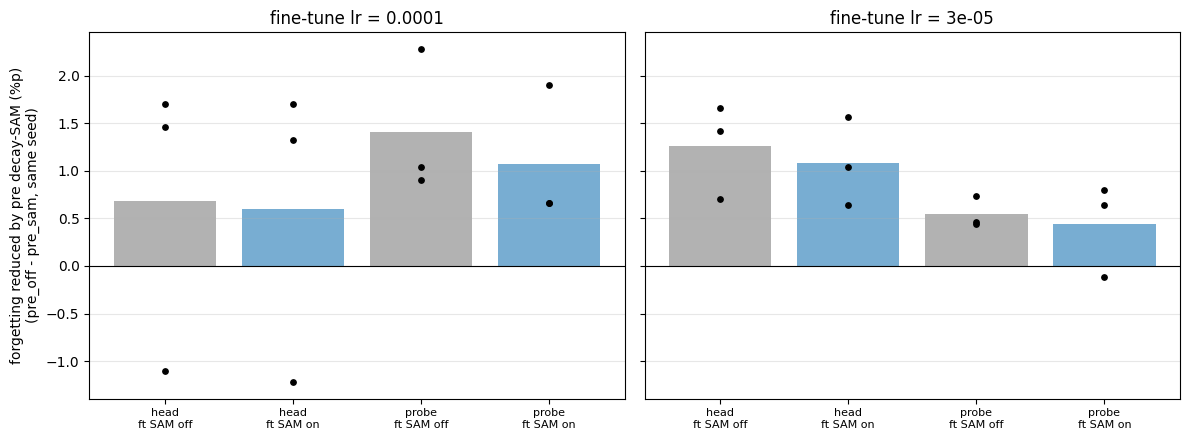

저장: /kaggle/working/exp_adamw


In [7]:
# ============ 새 셀 7: 결과 정리 ============
import matplotlib.pyplot as plt
df = pd.DataFrame(rows)

print('===== 1. 망각 수준 확인 (retained_drop이 10~30%p 정도면 측정하기 좋은 구간) =====')
display(df.groupby(['lr', 'pre', 'ft'])[['aircraft_acc', 'imnet_after', 'retained_drop',
                                          'recoverable_drop', 'cka', 'delta_rel']].mean().round(2))

print('\n===== 2. 핵심: 같은 seed끼리 짝지은 차이 (양수 = 사전학습 decay-SAM이 덜 잊음) =====')
PAIR = []
for lr in FT_LRS:
    for ft, label in [('ft_off', '파인튜닝 SAM 끔'), ('ft_sam', '파인튜닝 SAM 켬')]:
        a = df[(df.lr == lr) & (df.ft == ft) & (df.pre == 'pre_off')].set_index('seed').sort_index()
        b = df[(df.lr == lr) & (df.ft == ft) & (df.pre == 'pre_sam')].set_index('seed').sort_index()
        print(f'\n[lr={lr:g} / {label}]')
        for metric, name, sign in [('retained_drop', '원래 head 망각', 1), ('recoverable_drop', 'probe 정보 손실', 1),
                                   ('cka', 'CKA (특징 보존)', -1), ('aircraft_acc', 'Aircraft 정확도', -1)]:
            d = sign * (a[metric] - b[metric])
            unit = '' if metric == 'cka' else '%p'
            print(f'  {name:14s}: 평균 {d.mean():+.3f}{unit}  (std {d.std():.3f})  seed별 {[round(x, 2) for x in d]}  양수 {int((d > 0).sum())}/{len(d)}')
            PAIR.append(dict(lr=lr, ft=ft, metric=metric, mean=d.mean(), std=d.std(), values=list(d)))
json.dump(PAIR, open(f'{OUT}/ft_sweep_paired.json', 'w'), indent=2, default=float)

fig, axes = plt.subplots(1, len(FT_LRS), figsize=(6 * len(FT_LRS), 4.5), sharey=True)
for ax, lr in zip(np.atleast_1d(axes), FT_LRS):
    xs, labels = 0, []
    for metric, mname in [('retained_drop', 'head'), ('recoverable_drop', 'probe')]:
        for ft in ['ft_off', 'ft_sam']:
            p = [q for q in PAIR if q['lr'] == lr and q['ft'] == ft and q['metric'] == metric][0]
            ax.bar(xs, p['mean'], color='tab:blue' if ft == 'ft_sam' else 'tab:gray', alpha=0.6)
            ax.scatter([xs] * len(p['values']), p['values'], color='k', s=15, zorder=3)
            labels.append(f'{mname}\nft SAM {"on" if ft == "ft_sam" else "off"}'); xs += 1
    ax.axhline(0, color='k', lw=0.8)
    ax.set_xticks(range(xs)); ax.set_xticklabels(labels, fontsize=8)
    ax.set_title(f'fine-tune lr = {lr:g}'); ax.grid(axis='y', alpha=0.3)
np.atleast_1d(axes)[0].set_ylabel('forgetting reduced by pre decay-SAM (%p)\n(pre_off - pre_sam, same seed)')
plt.tight_layout(); plt.savefig(f'{OUT}/ft_sweep_paired.png', dpi=150); plt.show()
print('저장:', OUT)